# Sentence Embeddings — SBERT

## Goal
Version 2 — replace TF-IDF with sentence embeddings.
SBERT (Sentence-BERT) maps sentences to dense vectors
where similar sentences are close in vector space.

## Question
Can embeddings capture similarity between sentences
that share no common words?

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

## 1. Load Model and Encode Sentences

In [2]:
# Load pre-trained SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Same sentences as TF-IDF baseline
sentences = {
    "Group A — ML": [
        "Machine learning models learn from data",
        "AI systems improve through training on examples",
        "Algorithms extract patterns from datasets",
    ],
    "Group B — Weather": [
        "The weather today is sunny and warm",
        "It is a beautiful clear day outside",
        "The sky is bright and the temperature is high",
    ],
    "Group C — Food": [
        "I love eating pizza and pasta",
        "Italian cuisine is my favorite food",
        "Nothing beats a good slice of pizza",
    ]
}

all_sentences = [s for group in sentences.values() for s in group]

# Encode
print("Encoding sentences...")
embeddings = model.encode(all_sentences)
print(f"Done! Embedding shape: {embeddings.shape}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 22469.10it/s]


Encoding sentences...
Done! Embedding shape: (9, 384)


## 2. Compute Similarity Matrix

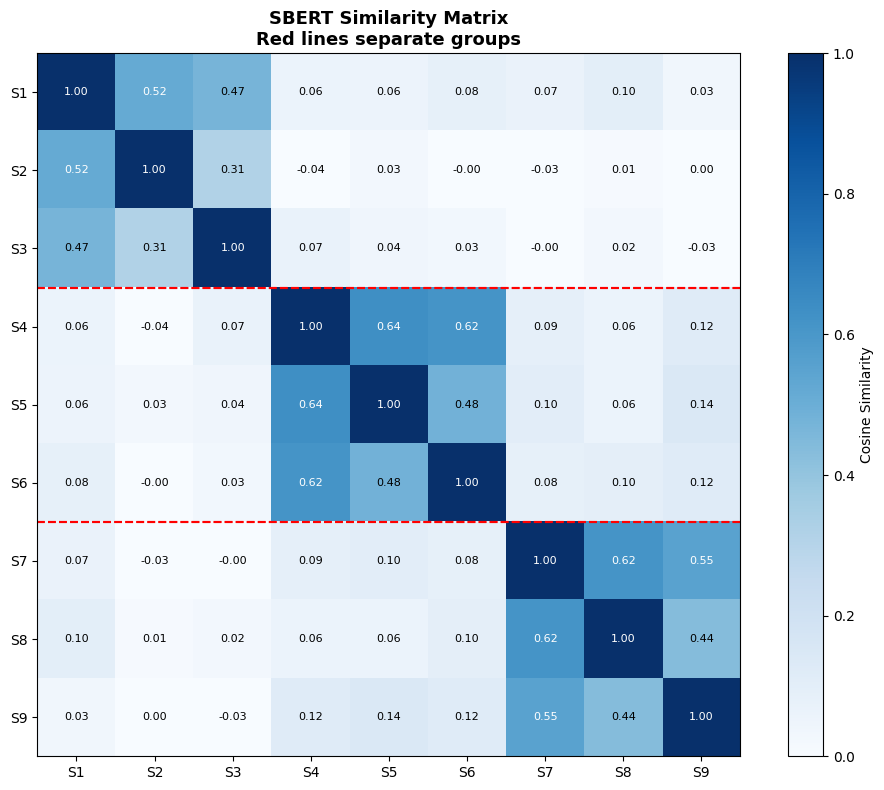

In [3]:
# Compute pairwise similarity
sim_matrix = cosine_similarity(embeddings)

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

labels = [f"S{i+1}" for i in range(len(all_sentences))]
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(all_sentences)))
ax.set_yticks(range(len(all_sentences)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(all_sentences)):
    for j in range(len(all_sentences)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
               ha="center", va="center", fontsize=8,
               color="white" if sim_matrix[i,j] >0.5 else "black")

for line in [2.5, 5.5]:
    ax.axhline(line, color="red", linewidth=1.5, linestyle="--")
    ax.axhline(line, color="red", linewidth=1.5, linestyle="--")

plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("SBERT Similarity Matrix\nRed lines separate groups",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sbert_similarity_matrix.png", dpi=300)
plt.show()
    

## 3. TF-IDF vs SBERT Comparison

| Pair | TF-IDF | SBERT | Winner |
|------|--------|-------|--------|
| S1 vs S2 (ML) | 0.00 | 0.52 | SBERT |
| S4 vs S5 (Weather) | 0.08 | 0.64 | SBERT |
| S7 vs S8 (Food) | 0.00 | 0.62 | SBERT |

## Key Insight
SBERT captures semantic similarity even when sentences share no words.
"Machine learning models learn from data" and
"AI systems improve through training on examples"
have zero word overlap but SBERT scores them 0.52.

## How SBERT Works
SBERT fine-tuned BERT on sentence pairs labeled as similar/dissimilar.
It learned to map sentences with similar meaning close together in vector space.
This is fundamentally different from TF-IDF which only counts word frequency.

## Next
Can transformer embeddings do even better?
-> 03_transformer_embeddings.ipynb